# Template 05: Model Training

**Purpose:** Train XGBoost model and generate predictions

**Inputs:**
- data/04_train.parquet
- data/04_test.parquet

**Outputs:**
- models/xgb_model.json
- results/05_metrics.yaml
- results/05_predictions.parquet

In [1]:
config_path = "config/car_coll/v1"

In [2]:
# Parameters
config_path = "config/car_coll/v1"


In [3]:
import matplotlib
matplotlib.use('Agg')  # Non-interactive backend for papermill

import pandas as pd
import numpy as np
import xgboost as xgb
import yaml
import os
import sys
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

sys.path.insert(0, str(Path.cwd() / 'lib'))
from utils import setup_notebook_environment

print("########################################")
print("# STAGE 05: MODEL TRAINING")
print("########################################")

project_root = setup_notebook_environment()

########################################
# STAGE 05: MODEL TRAINING
########################################


In [4]:
config_file = f"{config_path}/config.yaml"
with open(config_file, 'r') as f:
    cfg = yaml.safe_load(f)

output_base = cfg['paths']['output_base']
target = cfg['experiment']['target']

In [5]:
# Load train/test data
train = pd.read_parquet(f"{output_base}/data/04_train.parquet")
test = pd.read_parquet(f"{output_base}/data/04_test.parquet")

print(f"\n* Train: {train.shape}")
print(f"* Test: {test.shape}")


* Train: (2716120, 109)
* Test: (2707950, 109)


In [6]:
# Load feature list
features_df = pd.read_csv(f"{config_path}/{cfg['features']['inclusion_file']}", comment='#')
feature_cols = features_df['column_name'].tolist()

# Filter to available features
available_features = [f for f in feature_cols if f in train.columns]
print(f"\n* Features: {len(available_features)}/{len(feature_cols)} available")

X_train = train[available_features]
y_train = train[target]
X_test = test[available_features]
y_test = test[target]


* Features: 90/90 available


In [7]:
# Train XGBoost model
print(f"\n* Training XGBoost...")

xgb_params = cfg['xgboost'].copy()
n_estimators = xgb_params.pop('n_estimators', 5000)

model = xgb.XGBRegressor(n_estimators=n_estimators, **xgb_params)
model.fit(X_train, y_train, verbose=100)

print(f"\n* Model trained")


* Training XGBoost...



* Model trained


In [8]:
# Predictions
train['pred'] = model.predict(X_train)
test['pred'] = model.predict(X_test)

# Metrics
train_mae = mean_absolute_error(y_train, train['pred'])
test_mae = mean_absolute_error(y_test, test['pred'])
train_rmse = np.sqrt(mean_squared_error(y_train, train['pred']))
test_rmse = np.sqrt(mean_squared_error(y_test, test['pred']))

print(f"\n* Metrics:")
print(f"  Train MAE: {train_mae:.4f}")
print(f"  Test MAE: {test_mae:.4f}")
print(f"  Train RMSE: {train_rmse:.4f}")
print(f"  Test RMSE: {test_rmse:.4f}")


* Metrics:
  Train MAE: 348.8494
  Test MAE: 372.1643
  Train RMSE: 14973.8742
  Test RMSE: 25140.7746


In [9]:
# Save model
model_file = f"{output_base}/models/xgb_model.json"
os.makedirs(f"{output_base}/models", exist_ok=True)
model.save_model(model_file)
print(f"\n* Model saved: {model_file}")


* Model saved: output/car_coll/v1/models/xgb_model.json


In [10]:
# Save metrics
metrics = {
    'train_mae': float(train_mae),
    'test_mae': float(test_mae),
    'train_rmse': float(train_rmse),
    'test_rmse': float(test_rmse),
    'n_features': len(available_features),
    'train_size': len(train),
    'test_size': len(test)
}

metrics_file = f"{output_base}/results/05_metrics.yaml"
with open(metrics_file, 'w') as f:
    yaml.dump(metrics, f)

print(f"* Metrics saved: {metrics_file}")

* Metrics saved: output/car_coll/v1/results/05_metrics.yaml


In [11]:
# Save predictions
pred_file = f"{output_base}/results/05_predictions.parquet"
test[['pred', target]].to_parquet(pred_file)
print(f"* Predictions saved: {pred_file}")

* Predictions saved: output/car_coll/v1/results/05_predictions.parquet


## Lift Charts

In [12]:
# Prepare data for lift charts
# Get exposure column from config, or use fallback logic
exposure_col = cfg['experiment'].get('exposure', None)

if exposure_col and exposure_col in train.columns:
    weight_col = exposure_col
    print(f"\n* Using '{exposure_col}' from config as weight column")
elif 'ee' in train.columns:
    weight_col = 'ee'
    print(f"\n* Using 'ee' (earned exposure) as weight column")
elif 'ee_imps' in train.columns:
    weight_col = 'ee_imps'
    print(f"\n* Using 'ee_imps' (earned exposure imputed) as weight column")
else:
    train['weight'] = 1  # Equal weight per record
    test['weight'] = 1
    weight_col = 'weight'
    print(f"\n* WARNING: No exposure column found, using equal weighting (weight=1)")
    if exposure_col:
        print(f"  Config specifies '{exposure_col}' but it's not in the data!")

# Create incurred/denom columns for lift chart
# Use exposure as denominator if available
if weight_col in train.columns and weight_col != 'weight':
    train['incurred_act'] = train[target]
    train['incurred_pred'] = train['pred']
    train['denom'] = train[weight_col]  # Use exposure as denominator
    
    test['incurred_act'] = test[target]
    test['incurred_pred'] = test['pred']
    test['denom'] = test[weight_col]
else:
    train['incurred_act'] = train[target]
    train['incurred_pred'] = train['pred']
    train['denom'] = 1  # Equal weight
    
    test['incurred_act'] = test[target]
    test['incurred_pred'] = test['pred']
    test['denom'] = 1

print(f"* Prepared data for lift charts (weight_col='{weight_col}')")


* WARNING: No exposure column found, using equal weighting (weight=1)
  Config specifies 'ee_bi' but it's not in the data!
* Prepared data for lift charts (weight_col='weight')


In [13]:
# Load optimized lift chart function
import matplotlib.pyplot as plt
from lift_chart_fast import create_lift_chart

print("* Optimized lift chart function loaded")

* Optimized lift chart function loaded


In [14]:
print("\n* Generating train lift chart...")



* Generating train lift chart...


In [15]:
fig_train, table_train = create_lift_chart(train, weight_col, bins=10, title="Train Lift Chart")

  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 5 columns from 2,716,120 rows...


  [STEP 2] Done in 0.047s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.3s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.009s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.030s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.082s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 0.5s


  Saved: output/car_coll/v1/results/05_lift_chart_train.png


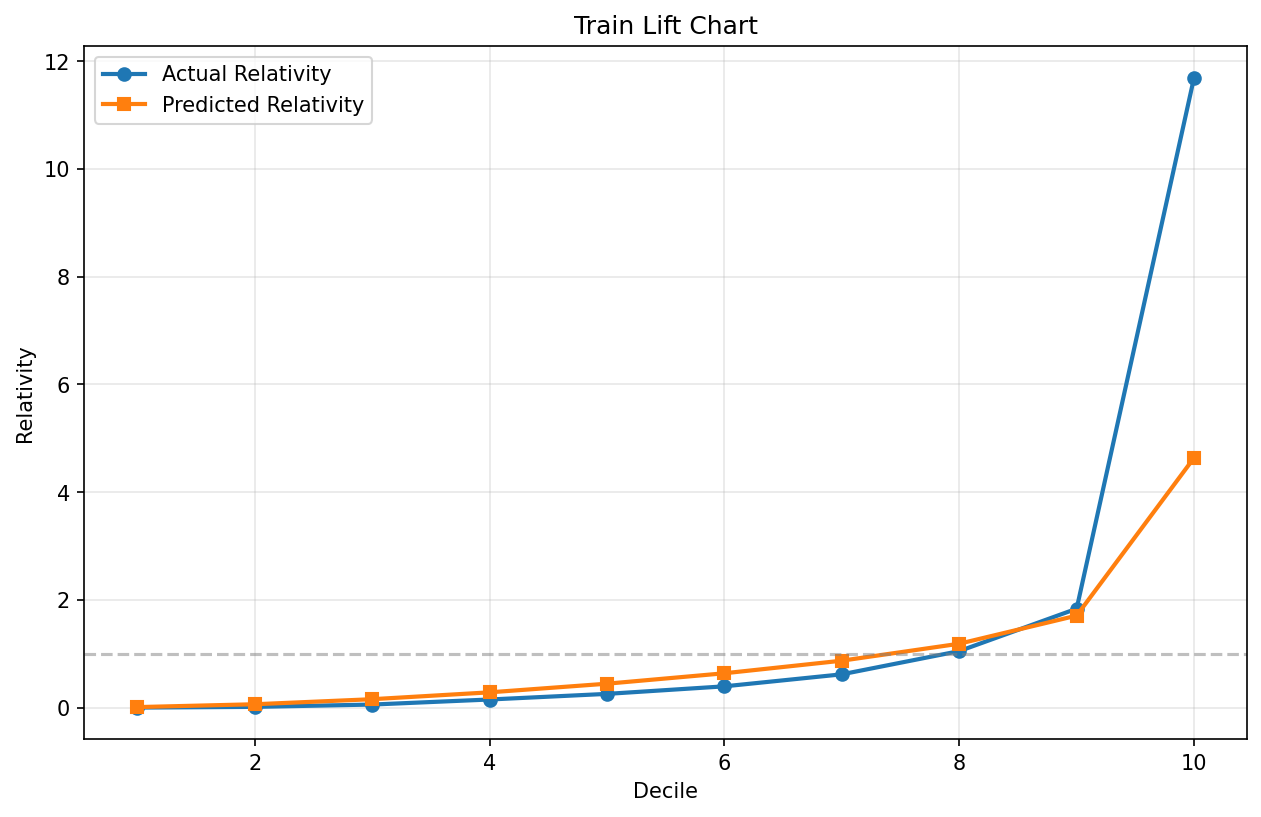


Train decile table:
   decile          act        pred    act_rel  pred_rel
0       1     0.147676    1.393139   0.001083  0.010217
1       2     1.939519    8.573193   0.014225  0.062877
2       3     7.807869   21.361368   0.057264  0.156666
3       4    20.605199   38.724029   0.151120  0.284006
4       5    34.815531   60.602845   0.255340  0.444467
5       6    53.902755   86.985199   0.395328  0.637957
6       7    84.321779  118.830486   0.618424  0.871514
7       8   143.057883  161.753766   1.049200  1.186317
8       9   250.402809  232.914996   1.836477  1.708220
9      10  1594.630199  632.356567  11.695165  4.637762


In [16]:
# Train lift chart


train_chart_file = f"{output_base}/results/05_lift_chart_train.png"
fig_train.savefig(train_chart_file, dpi=150, bbox_inches='tight')
plt.close(fig_train)

print(f"  Saved: {train_chart_file}")

# Display inline in notebook
from IPython.display import Image, display
display(Image(train_chart_file))

print("\nTrain decile table:")
print(table_train[['decile', 'act', 'pred', 'act_rel', 'pred_rel']])


* Generating test lift chart...
  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 5 columns from 2,707,950 rows...
  [STEP 2] Done in 0.040s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.3s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.008s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.029s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.069s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 0.5s
  Saved: output/car_coll/v1/results/05_lift_chart_test.png


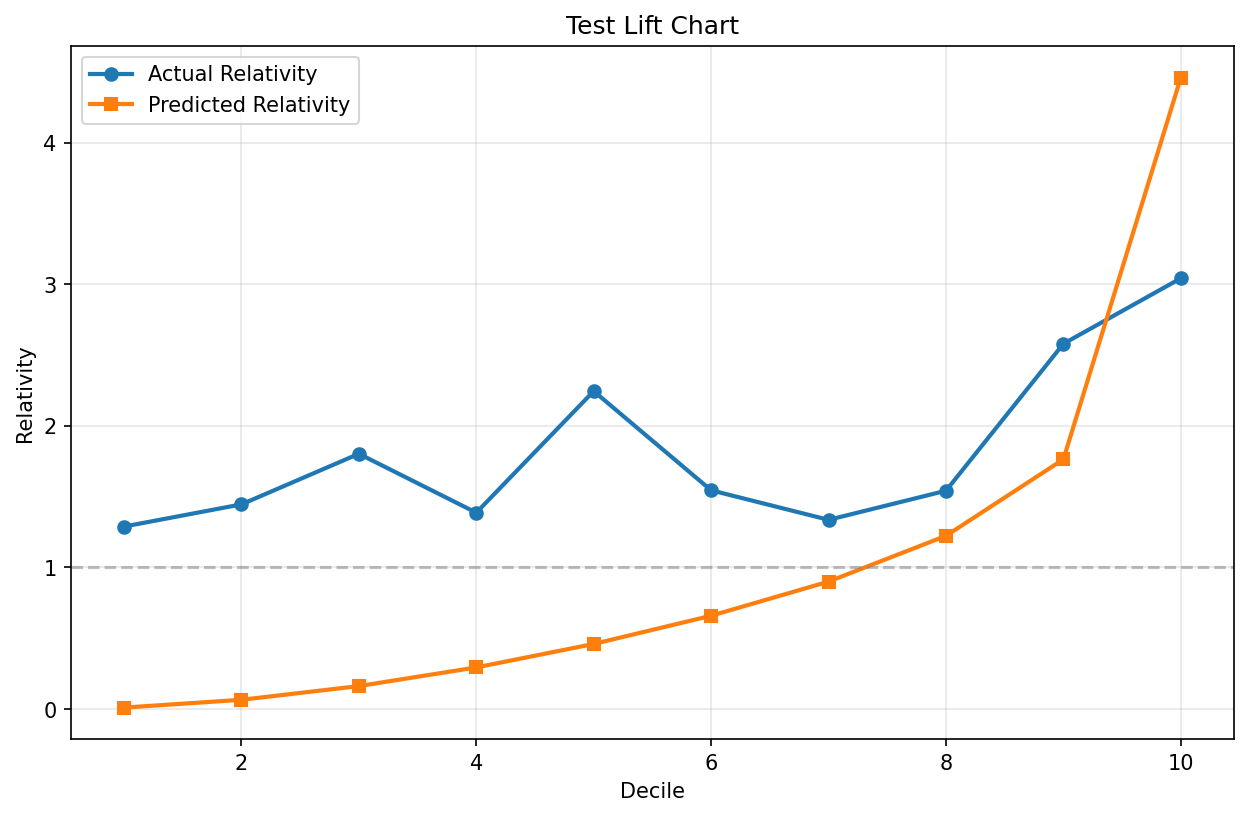


Test decile table:
   decile         act        pred   act_rel  pred_rel
0       1  170.485374    1.401182  1.289051  0.010594
1       2  191.206850    8.675607  1.445727  0.065597
2       3  238.458633   21.487487  1.803001  0.162468
3       4  183.444154   38.908902  1.387033  0.294193
4       5  296.982888   60.818985  2.245507  0.459856
5       6  204.355190   87.184778  1.545143  0.659210
6       7  176.752189  119.094141  1.336435  0.900478
7       8  203.943522  161.830580  1.542030  1.223611
8       9  341.216950  233.314928  2.579963  1.764109
9      10  402.378511  589.848823  3.042410  4.459885


In [17]:
# Test lift chart
print("\n* Generating test lift chart...")
fig_test, table_test = create_lift_chart(test, weight_col, bins=10, title="Test Lift Chart")

test_chart_file = f"{output_base}/results/05_lift_chart_test.png"
fig_test.savefig(test_chart_file, dpi=150, bbox_inches='tight')
plt.close(fig_test)

print(f"  Saved: {test_chart_file}")

# Display inline in notebook
display(Image(test_chart_file))

print("\nTest decile table:")
print(table_test[['decile', 'act', 'pred', 'act_rel', 'pred_rel']])

In [18]:
print("\n########################################")
print("# STAGE 05: COMPLETE")
print("########################################")


########################################
# STAGE 05: COMPLETE
########################################
